In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Representational similarity analysis between two synthetic neural manifolds

In this notebook, we walk through a demonstration of representational similarity analysis (RSA) using synthetically generated neural manifolds. The goal is to simulate two distinct sets of neural population activity patterns (manifolds) and assess their similarity via similarity metrics. This can help us understand how well-separated neural representations are in high-dimensional space, which is a useful tool in neuroscience.

## 1. Generate Synthetic Neural Manifolds

We begin by generating synthetic neural manifolds using the `generate_synthetic_manifolds` function from the `catrace` package. Each manifold contains `num_points_per_manifold` points in a high-dimensional space with dimensionality equal to `num_neurons`. The centers of the manifolds are separated by an expected distance defined by `center_dist`, and noise is added to each manifold based on the specified `noise_std_list`.

The output is a pandas DataFrame where each row represents a data point across all manifolds, and columns represent individual neurons.

In [8]:
from catrace.synthetic_manifold import generate_synthetic_manifolds

manifold_df = generate_synthetic_manifolds(
    num_manifolds=2,
    num_points_per_manifold=50,
    num_neurons=40,
    center_dist=5.0,
    noise_std_list=[2.5, 1.5],
)

manifold_df

neuron,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
manifold,,,,,,,,,,,,,,,,,,,,,
0,3.314608,3.712376,2.528158,-8.835910,-5.111797,2.839628,-9.077400,0.262861,0.319440,2.549779,...,2.285489,-6.853570,0.091835,-0.276972,-1.306634,6.193576,7.805864,-6.293339,9.012091,3.736874
0,1.342009,5.757862,6.416411,-3.185340,-3.051158,10.180294,-7.646960,0.518728,-4.502892,-7.274059,...,-4.840324,-5.212941,-4.150240,-2.703392,1.971661,1.674726,6.160873,-2.710562,11.068333,-4.333945
0,3.069582,5.514756,13.055778,-6.497521,0.108017,7.180082,-8.875832,1.311816,1.490162,-5.277391,...,-0.118164,-5.157391,-0.182148,1.281192,-0.199603,5.374137,4.592851,0.193948,7.522390,-0.164999
0,3.242289,2.023296,13.158630,-6.266902,-1.194227,5.372269,-10.692004,4.201414,3.011670,0.808132,...,-3.310775,-7.072744,1.948277,-2.259482,-1.765829,6.118201,6.514599,-4.681265,6.342327,1.636170
0,-0.321837,3.539125,11.192490,-6.396237,-0.317805,11.082211,-11.695030,1.060993,0.902535,1.584827,...,-6.656359,-3.285870,-2.514317,1.519648,-2.498151,2.839449,8.184722,-5.013699,5.531456,-0.581011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,8.244047,-5.785211,4.788202,-5.513972,0.475559,11.697912,-7.109833,1.222604,0.790971,-9.220820,...,-0.670641,2.371008,-2.608263,-5.523179,3.802837,-7.417865,2.082426,-3.904823,-7.980451,4.229211
1,8.654386,-6.573044,4.947087,-5.925909,1.331600,14.146316,-8.635643,-1.039579,2.433607,-9.025336,...,-5.309460,4.181568,-1.067232,-0.956543,6.175093,-6.470025,2.892346,-3.297194,-7.831907,7.337429
1,8.981588,-7.389259,5.296019,-6.220404,0.438074,13.451854,-6.540268,0.393552,2.734077,-9.873195,...,-3.127922,2.615996,-3.444817,-2.896687,3.433623,-6.443813,0.058662,-5.274419,-5.208842,5.636618


# 2. Visualize the manifolds

Next, we visualize the synthetic manifolds in a 2D plot. We reduce the dimensionality of the synthetic data using Principal Component Analysis (PCA) and plot the first two principal components.

Text(0, 0.5, 'PC2')

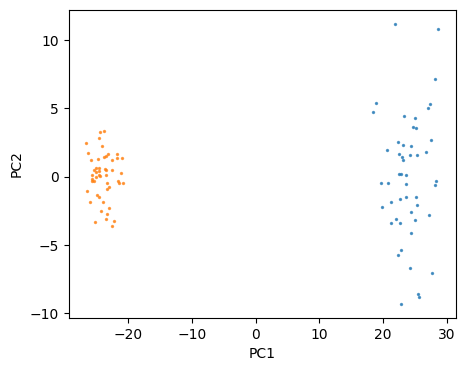

In [9]:
import matplotlib.pyplot as plt
from catrace.dimensionality_reduction import (compute_pca, plot_embed_2d)

embed = compute_pca(manifold_df, n_components=2)
fig, ax = plt.subplots(figsize=(5, 4))
plot_embed_2d(embed, component_idx=(0,1), ax=ax)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

## 3. Similarity between mean activity patterns

First, we compute the mean activity pattern (or center) of each manifold by averaging across all its data points. Then we compute the similarity between the mean activity patterns of the manifolds using two metrics:

- Cosine distance: Measures angular difference between vectors (1 = orthogonal, 0 = identical direction). The larger the cosine distance, the less similar the patterns are.

- Pattern correlation: Computes the Pearson correlation between the mean vectors. The closer the correlation is to 1, the more similar the patterns are.

##### Mathematical Definitions

Let $ \mathbf{x}, \mathbf{y} \in \mathbb{R}^n $ be two vectors.

- **Cosine distance**:

$$
d_{cos}(\mathbf{x}, \mathbf{y}) = 1 - \frac{\mathbf{x} \cdot \mathbf{y}}{\|\mathbf{x}\| \, \|\mathbf{y}\|}
$$

- **Pattern correlation** (Pearson correlation):

$$
\text{corr}(\mathbf{x}, \mathbf{y}) = \frac{(\mathbf{x} - \bar{x}) \cdot (\mathbf{y} - \bar{y})}{\|\mathbf{x} - \bar{x}\| \, \|\mathbf{y} - \bar{y}\|}
$$

where $ \bar{x} $ and $ \bar{y} $ are the means of $ \mathbf{x} $ and $ \mathbf{y} $ respectively, i.e. $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i $ and $ \bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i $.


Note that the output of the similarity funcion is a matrix, where the diagonal elements represent the similarity of pattern with itself (which is always 1), and the off-diagonal elements represent the similarity between different patterns.



In [10]:
# Mean activity patterns
manifold_centers = manifold_df.groupby('manifold').mean()
manifold_centers

# Similarity between mean activity patterns
from catrace.similarity import (cosine_distance, pattern_correlation)
cos_dist = cosine_distance(manifold_centers.values)
corr = pattern_correlation(manifold_centers.values)
print("Cosine distance between mean activity patterns: {:.3f}".format(cos_dist[0, 1]))
print("Cosine similarity between mean activity patterns: {:.3f}".format(1 - cos_dist[0, 1]))
print("Correlation between mean activity patterns: {:.3f}".format(corr[0, 1]))

Cosine distance between mean activity patterns: 0.918
Cosine similarity between mean activity patterns: 0.082
Correlation between mean activity patterns: 0.064


## 4. Distances between manifolds

We next quantify how far apart the two manifolds are using a variety of metrics.

First, we introduce the definitions of Euclidean distance between two points $\mathbf{x}$, $\mathbf{y}$ in an n-dimensional space $\mathbb{R}^n$:

Let $ \mathbf{x}, \mathbf{y} \in \mathbb{R}^n $ be two points in n-dimensional space. The Euclidean distance between them is defined as:
$$ d_E(\mathbf{x}, \mathbf{y}) = \sqrt{(\mathbf{x} - \mathbf{y})^T (\mathbf{x} - \mathbf{y})}. $$

In addition, we defined the Mahalanobis distance from a point $ \mathbf{x} $ to a distribution $ Y $ with mean $ \mu_Y $ and covariance matrix $ S_Y $ as:
$$ d_M(\mathbf{x}, Y) = \sqrt{(\mathbf{x} - \mu_Y)^T S_Y^{-1} (\mathbf{x} - \mu_Y)}. $$

Next, we extend the definitions of these distances to distances between manifolds. For this purpose, we extend in two ways: the distance with respect to manifold centers and the mean pointwise distance.

- **Center distances**:
  - The center Euclidean distance $ d^c_E$ between two manifolds $ X, Y \in \mathbb{R}^n$ is defined as
    $$
    d^c_E(X, Y) = d_E(\mu_{X}, \mu_{Y}) ,
    $$
    where $ \mu_{X} $ and $ \mu_{Y} $ are the means (centers) of the manifolds $ X $ and $ Y $, respectively.
  - The center Mahalanobis distance $ d^c_M$ from manifold $ X $ to manifold $ Y $ is defined as
    $$
    d^c_M(X, Y) = d_M(\mu_{X}, Y) .
    $$

- **Mean pointwise distance**:
  - The mean pointwise Euclidean distance $ d^p_E$ between two manifolds $ X, Y \in \mathbb{R}^n$ is defined as
    $$
    d^p_E(X, Y) = \frac{1}{|X|}
    \sum_{x \in X} d_E(x, \mu_{Y}) .
    $$
  - The mean pointwise Mahalanobis distance $ d^p_M$ from manifold $ X $ to manifold $ Y $ is defined as
    $$
    d^p_M(X, Y) = \frac{1}{|X|}
    \sum_{x \in X} d_M(x, Y) .
    $$

**Remarks:**
Note the except from $ d^c_E $, other distance metrics $d^c_M, d^p_E, d^p_M$ are asymmetric, due to geometrical difference between two mainfolds. Therefore, these metrics are not strictly distances, as defined mathematically. Here we abuse the term "distance" to refer to these metrics as they measure the separation between two manifolds.

In [11]:
# Distance between manifolds
from catrace.manifold_distance import (compute_center_distance, compute_mean_pointwise_distance)

manifold1 = manifold_df.loc[0].values
manifold2 = manifold_df.loc[1].values
center_dist_euc = compute_center_distance(
    manifold1, manifold2, metric='euclidean'
)
center_dist_mahal = compute_center_distance(
    manifold1, manifold2, metric='mahal', reg=1e-5
)
mean_pw_dist_euc = compute_mean_pointwise_distance(
    manifold1, manifold2, metric='euclidean'
)
mean_pw_dist_mahal = compute_mean_pointwise_distance(
    manifold1, manifold2, metric='mahal', reg=1e-5
)

print(f"Center Euclidean distance : {center_dist_euc}")
print(f"Center Mahalanobis distance: {center_dist_mahal}")
print(f"Mean pointwise Euclidean distance: {mean_pw_dist_euc}")
print(f"Mean pointwise Mahalanobis distance: {mean_pw_dist_mahal}")

Center Euclidean distance : 47.79079087985112
Center Mahalanobis distance: 91.7142683725232
Mean pointwise Euclidean distance: 50.236891958721515
Mean pointwise Mahalanobis distance: 95.05010186769509


### Assymmetries in metrics

We  compute the distance metrics in the reverse direction, i.e. from manifold 2 to manifold 1. Notice the difference in distance values compared to the original direction.

In [12]:
# Distance between manifolds in the reverse direction

center_dist_euc_rev = compute_center_distance(
    manifold2, manifold1, metric='euclidean'
)
center_dist_mahal_rev = compute_center_distance(
    manifold2, manifold1, metric='mahal', reg=1e-5
)
mean_pw_dist_euc_rev = compute_mean_pointwise_distance(
    manifold2, manifold1, metric='euclidean'
)
mean_pw_dist_mahal_rev = compute_mean_pointwise_distance(
    manifold2, manifold1, metric='mahal', reg=1e-5
)

print(f"Center distance (Euclidean, reverse): {center_dist_euc_rev}")
print(f"Center distance (Mahalanobis, reverse): {center_dist_mahal_rev}")
print(f"Mean pointwise distance (Euclidean, reverse): {mean_pw_dist_euc_rev}")
print(f"Mean pointwise distance (Mahalanobis, reverse): {mean_pw_dist_mahal_rev}")

Center distance (Euclidean, reverse): 47.79079087985112
Center distance (Mahalanobis, reverse): 38.05447479808103
Mean pointwise distance (Euclidean, reverse): 48.655865921606065
Mean pointwise distance (Mahalanobis, reverse): 39.33748274720379
